In [1]:
## Load Dataset
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Downloads\mushroom.csv")
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [2]:
## Basic EDA
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   str    
 2   cap_surface               2000 non-null   str    
 3   cap_color                 2000 non-null   str    
 4   bruises                   2000 non-null   str    
 5   odor                      2000 non-null   str    
 6   gill_attachment           2000 non-null   str    
 7   gill_spacing              2000 non-null   str    
 8   gill_size                 2000 non-null   str    
 9   gill_color                2000 non-null   str    
 10  stalk_shape               2000 non-null   str    
 11  stalk_root                2000 non-null   str    
 12  stalk_surface_above_ring  2000 non-null   str    
 13  stalk_surface_below_ring  2000 non-null   str    
 14  stalk_color_above_r

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [3]:
## Encode Data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [4]:
## Define X and y
X = df.drop('class', axis=1)   # target column is 'class'
y = df['class']

In [5]:
print(df.columns)

Index(['Unnamed: 0', 'cap_shape', 'cap_surface', 'cap_color', 'bruises',
       'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
       'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
       'stalk_surface_below_ring', 'stalk_color_above_ring',
       'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
       'ring_type', 'spore_print_color', 'population', 'habitat', 'class',
       'stalk_height', 'cap_diameter'],
      dtype='str')


In [6]:
## Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
## Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
## Apply SVM
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

In [10]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', class_weight='balanced')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.72      0.69      0.71       133
           1       0.85      0.87      0.86       267

    accuracy                           0.81       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.81      0.81      0.81       400



In [12]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    svm = SVC(kernel=k, class_weight='balanced')
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    
    print(f"\nKernel: {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))


Kernel: linear
Accuracy: 0.5225

Kernel: rbf
Accuracy: 0.81

Kernel: poly
Accuracy: 0.83


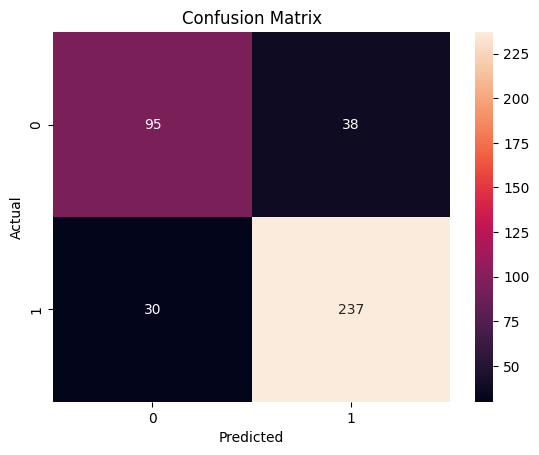

In [13]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
## Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}


In [15]:
## Train with BEST parameters
best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Accuracy: 0.8575
              precision    recall  f1-score   support

           0       0.82      0.74      0.77       133
           1       0.88      0.92      0.90       267

    accuracy                           0.86       400
   macro avg       0.85      0.83      0.84       400
weighted avg       0.86      0.86      0.86       400



In [16]:
df = df.drop(['Unnamed: 0'], axis=1)

## Conclusion 
Model Comparison
Linear kernel performed poorly (~52% accuracy)
RBF kernel improved performance (~81%)
Polynomial kernel achieved the best performance (~83%)

Strengths of SVM
Works well with high-dimensional data
Effective for classification problems
Handles non-linear data using kernels

Weaknesses of SVM
Slow for large datasets
Requires proper parameter tuning
Sensitive to feature scaling

Conclusion
SVM successfully classified mushroom data
Polynomial kernel gave best accuracy
Hyperparameter tuning improved performance
SVM is suitable for this classification problem